#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 3: Demanda de bicicletas compartidas  </center>

# Introducción

En esta actividad se trabajará sobre el *dataset* de la competencia [*Bike Sharing Demand*](https://www.kaggle.com/c/bike-sharing-demand) de *Kaggle*. El objetivo de la competencia, predecir la demanda de bicicletas a partir de la combinación de datos históricos sobre demanda y clima. 

El conjunto corresponde a datos de alquiler por hora y abarcan dos años de información. El subconjunto de *train* está compuesto por los primeros 19 días de cada mes, mientras que el subconjunto de *test* va desde 20 hasta el final del mes. Este último debe ser utilizado solamente en la parte 10 para subir los resultados a la página de la competencia.

En esta actividad nos centraremos en el algoritmo **Decision Trees**, el cual al igual que *SVM* es un algoritmo versatil que se utiliza en problemas tanto de clasificación como de regresión. También trabajaremos con algoritmos basados en métodos de ensamble de estimadores, como son **Random Forest** y **Gradient Boosting**, que utilizan como estimador base **Decision Trees**.


## Objetivos


*   Conocer los estimadores *Decision Trees*, entender cómo funcionan para un problema de regresión, ver ventajas y desventajas.
*   Familiarizarse con los métodos de ensamblado de estimadores y entender cual es el objetivo de usar estos métodos.
*   Incorporar una función de transformación de columnas y una función de medida de desempeño personalizadas.


## Formas de trabajo

#### Opción 1: Trabajar localmente

##### Descarga de datos disponibles en Kaggle

Luego, para descargar el dataset de IMDb reviews:

In [1]:
!kaggle competitions download -c bike-sharing-demand

bike-sharing-demand.zip: Skipping, found more recently modified local copy (use --force to force download)


Descomprima el archivo descargado:

In [2]:
import shutil
shutil.unpack_archive('./bike-sharing-demand.zip', './')

## Paquetes a utilizar

En esta actividad se utilizarán algunas bibliotecas auxiliares que deberán ser instaladas. Ejecutar la siguiente celda hasta que se ejecute sin errores. En caso de error, se puede instalar el paquete faltante desde el notebook con el comando:

`!pip install paquete_faltante`

In [3]:
#Importar librerias de ellos
from comet_ml import Experiment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## (Opcional) librería de visualización de datos
import seaborn as sns
sns.set_theme(style="whitegrid")

df_train = pd.read_csv('train.csv')

In [4]:
#Importar mis cosas
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_squared_log_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV, cross_val_predict, cross_val_score
from sklearn.tree import plot_tree
import joblib  # Para guardar el modelo
from sklearn.ensemble import RandomForestRegressor


In [5]:
API_KEY = 'dSrKcsYZJjc7IfbOa6lyjtnlt' # Se puede encontrar en Settings(Arriba a la derecha en Comet)

In [6]:
#Comet:
def save_experiment_results(cmt_exp, train_scores, val_scores, kf):
    '''
    Entrada:
        cmt_exp: experimento comet
        train_scores: puntuaciones RMSLE de entrenamiento
        val_scores: puntuaciones RMSLE de validación
        kf: objeto KFold usado para la validación cruzada
    '''    
    n_splits = kf.n_splits  # Obtener el número de divisiones del KFold

    ### Resultados para cada fold ###
    for k in range(n_splits):
        metrics_step = {
            'Train RMSLE': train_scores[k],
            'Val RMSLE': val_scores[k],
        }
        cmt_exp.log_metrics(metrics_step, step=k)

    return

#### Objetivos

 - Analizar el conjunto de datos con las diferentes funciones de *pandas* que crea pertinente.

In [7]:
df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [8]:
df_train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [9]:
print('Cantidad de datos nulos:', df_train.isnull().sum().sum())

Cantidad de datos nulos: 0


Por lo que podemos decir que no hay datos faltantes.

#### Preguntas:


[Text(0.5, 1.0, 'Heatmap of Numerical Data')]

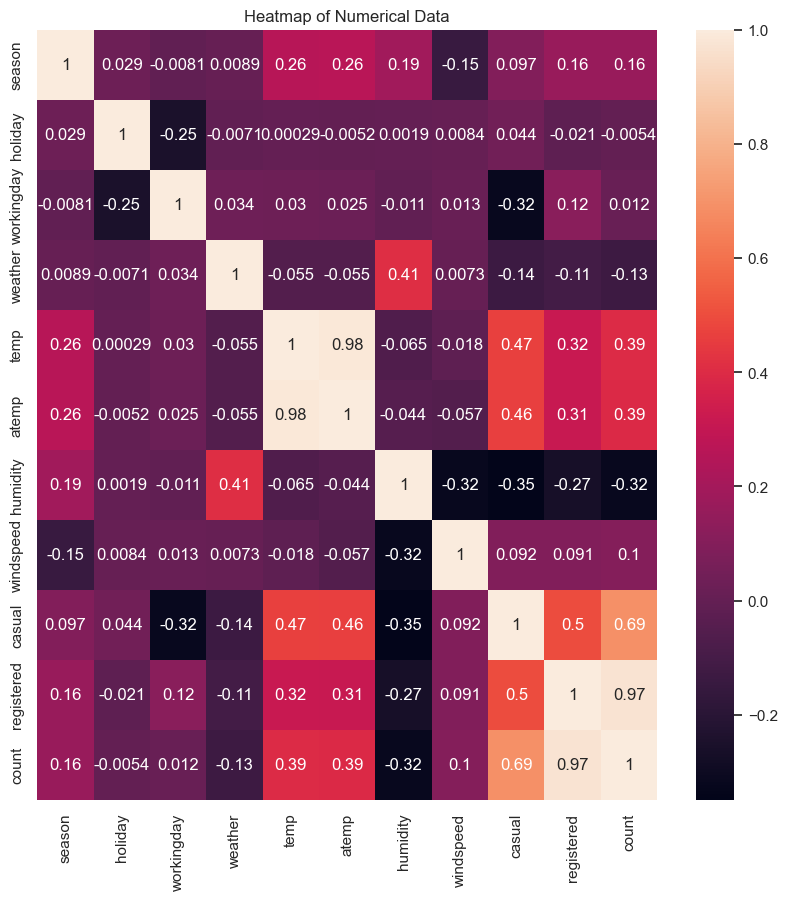

In [10]:
num_cols = ["season", "holiday", "workingday", "weather", "temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
corr_matrix = df_train[num_cols].corr()
fig, ax = plt.subplots()
fig.set_size_inches(10,10)
sns.heatmap(corr_matrix, annot=True)
ax.set(title="Heatmap of Numerical Data")

 - ¿Qué efecto tiene el tiempo (meteorológico) sobre el alquiler de bicicletas? ¿Es el mismo para clientes registrados y casuales? ¿Coincide esto con lo que asumiría a priori? 

<p style="font-size:13px; color:#BB0000;">Respuesta: </p>
Tiene un efecto negativo, ya que la correlación es negativa. Si se condice con lo que uno esperaría.


 - Vamos a trabajar con las codificaciones por defecto (salvo datetime que veremos en la Parte 2). ¿Le parece adecuado?

<p style="font-size:13px; color:#BB0000;">Respuesta: </p>

Me parece correcto



 - ¿Qué puede decir sobre la correlación entre *season* y *casual*?

<p style="font-size:13px; color:#BB0000;">Respuesta: </p>

Depende positivamente por lo que afecta.

## Parte 2 - Características temporales

La primer columna de los datos (*datetime*) corresponde a las marcas de tiempo asociadas a cada instancia. Para que estos tengan el orden cronológico que representan es necesario pasarlos de tipo *string* a tipo *datetime*. Para esto *Pandas* proporciona la función *to_datetime()*. Correr la siguiente celda para hacer el cambio.

In [11]:
df_train['datetime'] = pd.to_datetime(df_train['datetime'])

##### La figura siguiente muestra cómo varía la cantidad de bicicletas alquiladas en función del tiempo. 

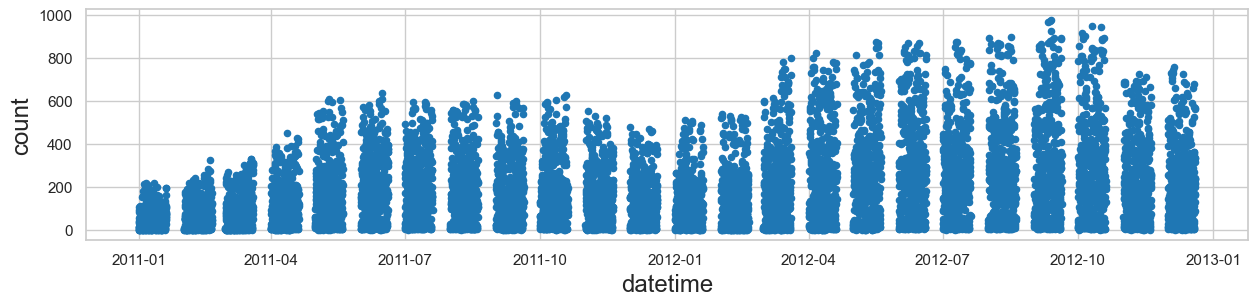

In [12]:
df_train.plot(x='datetime', y='count', figsize=[15,3],kind='scatter',color='tab:blue')
plt.xlabel('datetime',fontsize='x-large')
plt.ylabel('count',fontsize='x-large')
plt.show()

#### Preguntas:

- ¿Le parece razonable la division en conjuntos de train y test que se tomó en el desafío?
- ¿Cómo varían temporalmente (día, semana, mes, año) los alquileres?

In [13]:
# Añado columnas 'day', 'month' y 'year' según el datetime
df_train['day'] = df_train['datetime'].dt.day
df_train['month'] = df_train['datetime'].dt.month
df_train['year'] = df_train['datetime'].dt.year

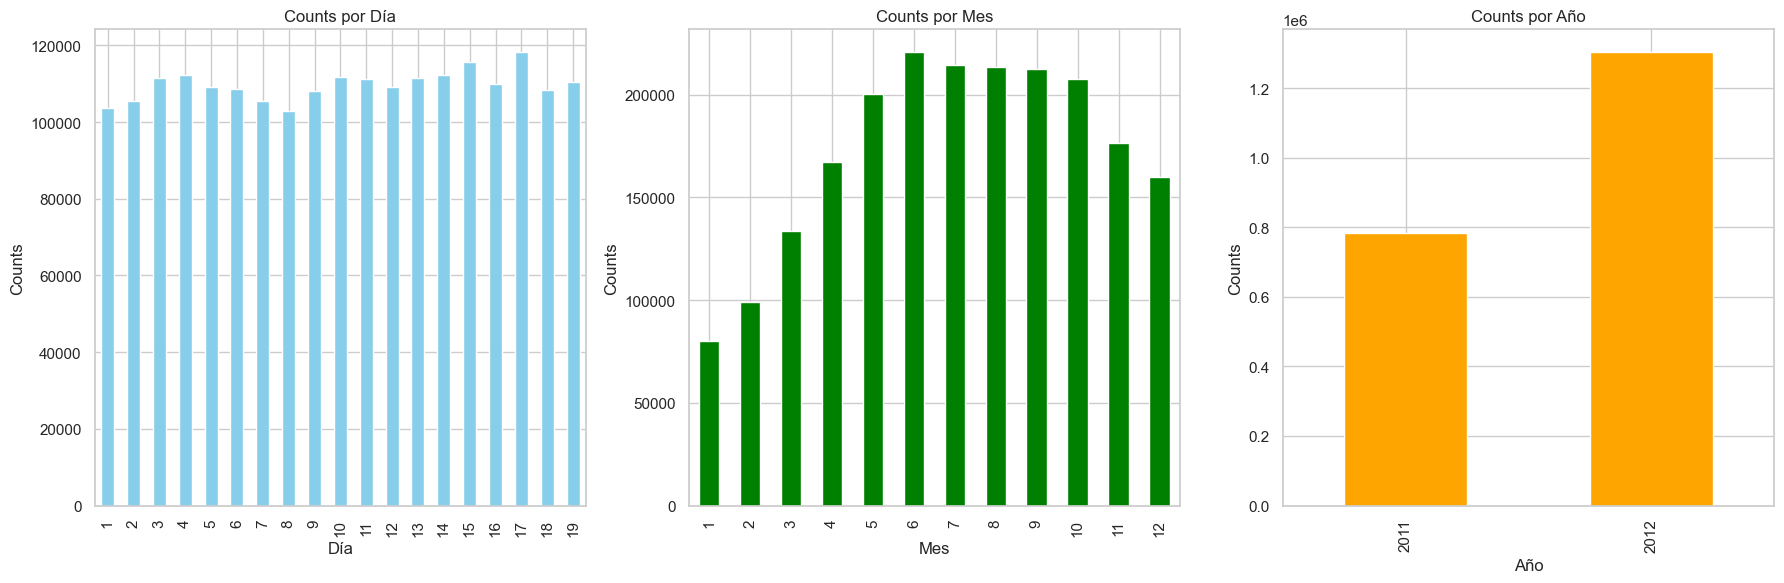

In [14]:
daily_counts = df_train.groupby('day')['count'].sum()
monthly_counts = df_train.groupby('month')['count'].sum()
yearly_counts = df_train.groupby('year')['count'].sum()

# Configurar los subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))  # figsize puede ajustarse según tus necesidades

# Gráfico por día
daily_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Counts por Día')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Counts')

# Gráfico por mes
monthly_counts.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Counts por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Counts')

# Gráfico por año
yearly_counts.plot(kind='bar', ax=axes[2], color='orange')
axes[2].set_title('Counts por Año')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Counts')

# Ajustar el layout para evitar superposición
plt.tight_layout()
# Mostrar los gráficos
plt.show()

<p style="font-size:13px; color:#BB0000;">Respuesta a preguntas </p>

La división no me parece del todo razonable la verdad. Como dice mauri: "Capaz a fin de mes tenés menos plata, por lo tanto la división no es del todo beneficiosa"

El tipo de dato *datetime* permite extraer de forma sencilla datos categóricos como la hora, el día de la semana, entre otros. La siguiente celda agrega a los datos de *train* estas nuevas características.

In [15]:
df_train['hour'] = df_train['datetime'].dt.hour
df_train['weekday'] = df_train['datetime'].dt.weekday
df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day,month,year,hour,weekday
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,1,2011,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,2011,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,1,2011,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,1,2011,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,1,2011,4,5


#### Ejercicio:

 - Grafique count, registered y casual en función de las horas y el día de la semana. ([*Sugerencia:*](https://seaborn.pydata.org/generated/seaborn.barplot.html) Ejemplos de la librería *seaborn*)

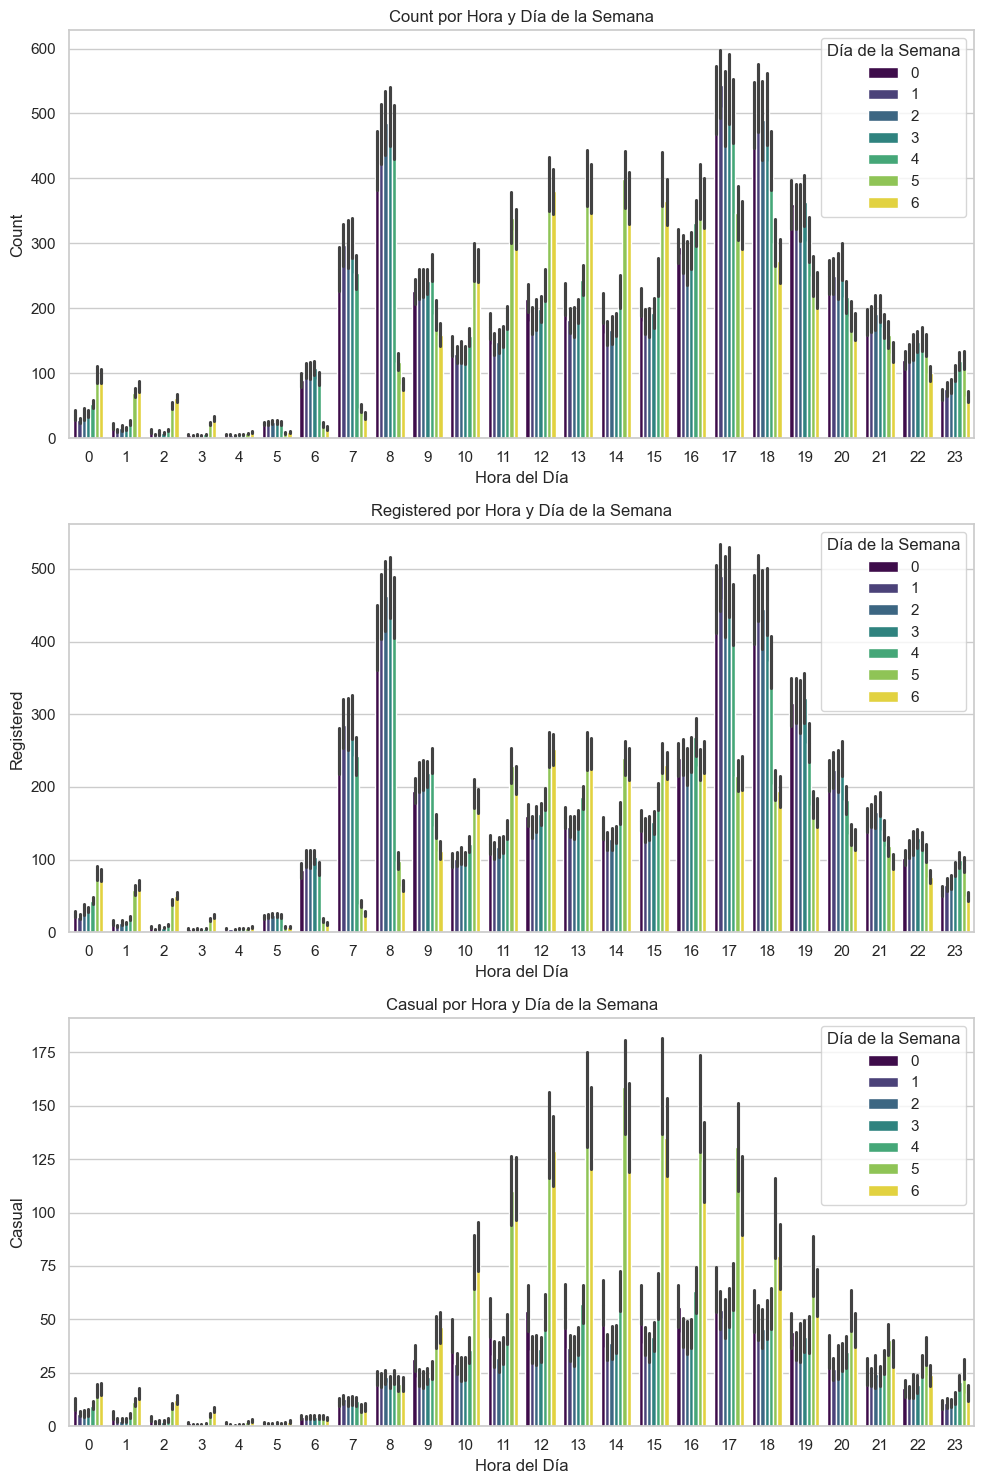

In [77]:
# Establece el estilo de los gráficos
sns.set(style="whitegrid")

# Crear un subplot de 3x1
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Gráfico para 'count' en función de la hora y el día de la semana
sns.barplot(x='hour', y='count', hue='weekday', data=df_train, ax=axes[0], palette='viridis')
axes[0].set_title('Count por Hora y Día de la Semana')
axes[0].set_xlabel('Hora del Día')
axes[0].set_ylabel('Count')
axes[0].legend(title='Día de la Semana', loc='upper right')

# Gráfico para 'registered' en función de la hora y el día de la semana
sns.barplot(x='hour', y='registered', hue='weekday', data=df_train, ax=axes[1], palette='viridis')
axes[1].set_title('Registered por Hora y Día de la Semana')
axes[1].set_xlabel('Hora del Día')
axes[1].set_ylabel('Registered')
axes[1].legend(title='Día de la Semana', loc='upper right')

# Gráfico para 'casual' en función de la hora y el día de la semana
sns.barplot(x='hour', y='casual', hue='weekday', data=df_train, ax=axes[2], palette='viridis')
axes[2].set_title('Casual por Hora y Día de la Semana')
axes[2].set_xlabel('Hora del Día')
axes[2].set_ylabel('Casual')
axes[2].legend(title='Día de la Semana', loc='upper right')

# Ajustar layout
plt.tight_layout()

# Mostrar los gráficos
plt.show()


##### A partir de las gráficas responder las siguientes preguntas:


### Pregunta:
 - ¿Cómo explicaría la diferencia entre las distribuciones de los clientes registrados y casuales? 

#### Respuesta:
Es claro ver que los fines de semana a la venta casual de bicis le va espectacular mientras que en la de registrados no tantos .

 ### Pregunta:
 - ¿Qué desventaja le encuentra a utilizar un regresor lineal para predecir los alquileres a partir de la hora del día?¿Cómo transformaría esta característica para paliar este problema?

 #### Respuesta: 
 La desventaja que veo es que los datos no son uniformes o lineales y están cargados en cierta hora del día entonces no sería una característica que sirva de mucho.
 Se puede estandarizar para tener una mejor distribución de los datos.

### Pregunta:
 - ¿Es necesaria esta transformación cuando se utilizan Árboles de Decisión?

#### Respuesta: 
No, generalmente no es necesario estandarizar o normalizar los datos cuando se utilizan árboles de decisión para modelado predictivo. 


#### Selección de Características:

*   Entre el día, el mes y el año ¿cuáles de estos datos les pareces agregar como nuevas características y cuáles no? y ¿Por qué?
*   Agregar las características seleccionadas.

El mes me parece la más representativa porque el año solo tenemos datos de solo dos y el día no es tan representativo.

## Parte 3 - Preparación de los datos y Métrica de evaluación

Previo a trabajar con los estimadores:

*   Apartar la columna objetivo y eliminarla del conjunto de entrenamiento. 
*   Eliminar las columnas *'casual'* y *'registered'*. ¿Por qué esto es necesario?.
*   Eliminar la columna *'datetime'*.

Durante la actividad los estimadores deben ser evaluados con la misma medida de desempeño utilizada en la competencia: 

Root Mean Squared Logarithmic Error (RMSLE)
$$\sqrt{\frac{1}{n}\sum_{i}^{n}\big(\log(y_{i} + 1) - \log(\hat{y}_{i} + 1)\big)^2}$$

Este tipo de medida se utiliza cuando los valores a estimar son grandes. La librería *Scikit-Learn* incluye la función de desempeño [*mean_squared_log_error*](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_log_error.html#sklearn.metrics.mean_squared_log_error) (MSLE), esta función se puede utilizar  para la validación ya que alcanza las mismas soluciones que su raíz (RMSLE). De igual forma los resultados se deben mostrar con RMSLE.

*   Apartar la columna objetivo y eliminarla del conjunto de entrenamiento:

In [16]:
y_train = df_train['count']
df_train = df_train.drop(['count'], axis=1)

*   Eliminar las columnas *'casual'* y *'registered'*. ¿Por qué esto es necesario?:

In [17]:
df_train = df_train.drop(['casual', 'registered'], axis=1)

<p style="font-size:13px; color:#BB0000;">Respuesta a pregunta: </p>

No son necesarias estas columnas ya que vos solo querés ver como cambia el alquiler con respecto a el clima y ver si son casuales o registrados no suman al problema.

*   Eliminar la columna *'datetime'*:

In [18]:
df_train = df_train.drop(['datetime'], axis=1)

## Parte 4 - Decision Trees

Observando los valores de las etiquetas se puede ver que la distribución de estos tiene una asimetría a la derecha, por lo que se puede aplicar una transformación logarítmica para que la distribución de las etiquetas sea más normal.

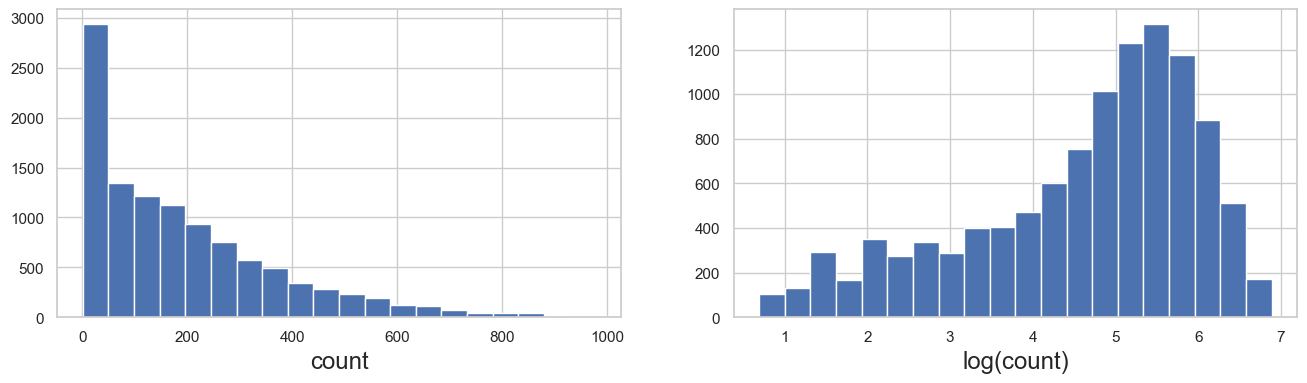

In [19]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
y_train.hist(bins=20)
plt.xlabel('count',fontsize='x-large')
plt.subplot(1,2,2)
np.log1p(y_train).hist(bins=20)
plt.xlabel('log(count)',fontsize='x-large')
plt.show()

Si le pasamos al regresor estas etiquetas tranformadas este predecirá el logaritmo de los alquileres, por lo que luego deberíamos calcular la exponencial del valor predicho. Por suerte, Scikit-Learn cuenta con la función [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html) que resuelve este problema.

**Nota: Consultar el Capítulo 2 del Libro del Curso por más información**

#### Objetivos

*   Importar la función *DecisionTreeRegressor()* de *Scikit-Learn* y utilizar *TransformedTargetRegressor* para tranformar logarítmicamente las etiquetas. Utilizar las funciones ***np.log1p*** y ***np.expm1*** para calcular el logaritmo y la exponencial respectivamente (ver ejemplo en ayuda de la función *TransformedTargetRegressor*).
*   Aplicar validación cruzada (10-Folds) a un estimador con los hiper-parámetros por defecto.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Para lo último utilizar la función *fill_between()* de *matplotlib*. 

**Nota:** Puede pasarle ***random-state=2*** al estimador,*DecisionTreeRegressor()*,  para controlar la aleatoreidad del mismo. De no hacerlo puede que los resultados que obtenga difieran en cierta medida de los esperados.

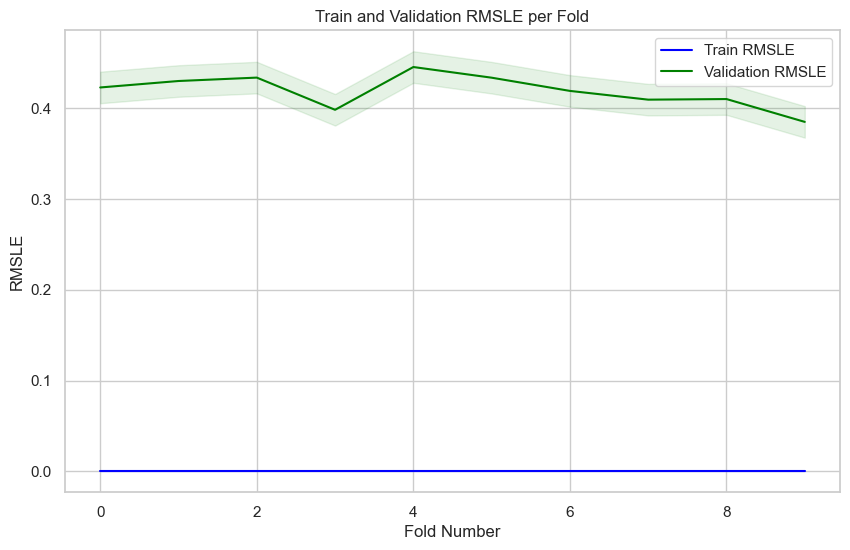

Mean Train RMSLE: 1.469449859896236e-17
Mean Validation RMSLE: 0.41893567548443783


In [20]:
def rmsle(y_true, y_pred):
    """Calculate the Root Mean Squared Logarithmic Error."""
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# Inicialización del modelo base usando DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(random_state=2)

# Crear el regressor con transformación de objetivo usando logaritmos
regressor = TransformedTargetRegressor(regressor=dt_regressor,
                                          func=np.log1p, 
                                          inverse_func=np.expm1)

# Crear el pipeline con el regressor transformado
regression_pipeline = Pipeline([
    ('transformed_target_regressor', regressor)
])

# Configuración de la validación cruzada
kf = KFold(n_splits=10, shuffle=True, random_state=2)

# Crear un scorer personalizado basado en RMSLE
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

# Ejecutar validación cruzada
cv_results = cross_validate(regression_pipeline, df_train, y_train, cv=kf, 
                            scoring=rmsle_scorer, return_train_score=True)

# Extraer scores de entrenamiento y validación, ajustar el signo
train_scores = -cv_results['train_score']
test_scores = -cv_results['test_score']

# Calcular la media y desviación estándar para el gráfico
train_mean = np.mean(train_scores)
train_std = np.std(train_scores)
test_mean = np.mean(test_scores)
test_std = np.std(test_scores)

# Crear la gráfica de desempeño
plt.figure(figsize=(10, 6))
plt.plot(train_scores, label='Train RMSLE', color='blue')
plt.plot(test_scores, label='Validation RMSLE', color='green')
plt.fill_between(range(len(train_scores)), train_scores - train_std, train_scores + train_std, color='blue', alpha=0.1)
plt.fill_between(range(len(test_scores)), test_scores - test_std, test_scores + test_std, color='green', alpha=0.1)
plt.title('Train and Validation RMSLE per Fold')
plt.xlabel('Fold Number')
plt.ylabel('RMSLE')
plt.legend()
plt.show()

# Mostrar estadísticas resumidas del desempeño
print("Mean Train RMSLE:", train_mean)
print("Mean Validation RMSLE:", test_mean)


#### Preguntas:

*   ¿Qué fenómeno se logra apreciar en el gráfico? ¿A qué se debe? ¿Por qué esto es un problema?
*   Indicar y describir alguno de los hiper-parámetros que la función *DecisionTreeRegressor()* ofrece para limitar la complejidad del estimador.

#### Respuesta: 

1) Lo que se ve es que el modelo de train está muy ajustado a los datos y tenemos un error visible dentro del conjunto de validación, aunque es algo chico no deja de ser grande. Esto es un problema porque luego en test no vamos a poder predecir de manera correcta.

2) Hiperparámetros:

max_depth: Controla la profundidad máxima del árbol. Limitar la profundidad puede evitar el sobreajuste al impedir que el árbol se vuelva demasiado profundo y complejo.

min_samples_split: Es el número mínimo de muestras requeridas para dividir un nodo interno. Este parámetro controla cuán "profundo" puede ser el árbol al imponer restricciones en la división de nodos.

min_samples_leaf: Es el número mínimo de muestras requeridas para ser una hoja (nodo final). Este parámetro controla el tamaño mínimo de las hojas del árbol, lo que puede influir en la regularización del modelo.

max_features: Es el número de características a considerar al buscar la mejor división. Limitar este valor puede reducir la complejidad del modelo y mejorar su generalización.

min_impurity_decrease: Es el valor mínimo que debe cumplirse para que una división ocurra. Controla la cantidad mínima de reducción de impureza requerida para realizar una división en el árbol.

max_leaf_nodes: Limita el número máximo de nodos finales (hojas) en el árbol. Esto puede controlar indirectamente la profundidad y complejidad del árbol.

#### Ejemplo Lack of smoothness

Como ejemplo se tomará la siguiente situación:

 - Domingo 
 - Despejado o Parcialmente nublado
 - A las 19 horas 
 - En primavera 
 
Se observará el efecto de la temperatura en la predicción de alquileres de bicicletas.

 - ¿Cómo espera que sea dicho efecto en un rango de 10°C a 30°C?

In [21]:
index = 2685
Domingo = df_train.iloc[index:index+1]
Domingo

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,day,month,year,hour,weekday
2685,2,0,0,1,29.52,34.09,62,8.9981,19,6,2011,19,6


In [22]:
## Se crea un dataframe con los datos del domingo
X_prueba = pd.concat([Domingo]*21,ignore_index=True)

index = 0
for k in np.linspace(10,30,21):
    X_prueba.loc[index,'temp']= k
    ## De igual manera se cambia la sensación térmica para mantener cierta coherencia
    X_prueba.loc[index,'atemp']= k
    index += 1

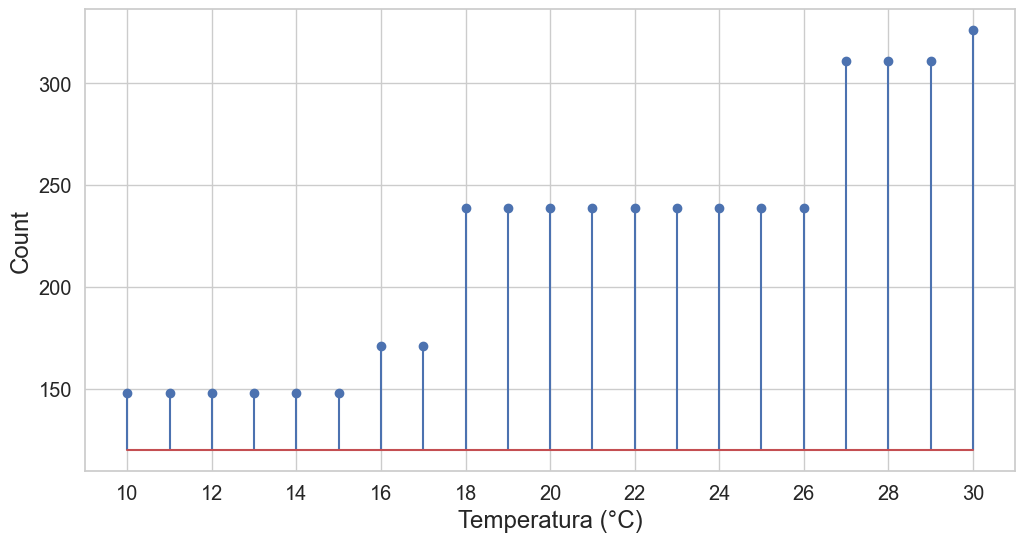

In [23]:
## regressor es el nombre de la variable que contiene el modelo de arbol de decisión
regression_pipeline.fit(df_train,y_train)

plt.figure(figsize=(12,6))
plt.stem(np.linspace(10,30,21),regression_pipeline.predict(X_prueba),bottom=120)
plt.xlabel('Temperatura (°C)',fontsize='x-large')
plt.ylabel('Count',fontsize='x-large')
plt.xticks(np.linspace(10,30,11),fontsize='large')
plt.yticks(fontsize='large')
plt.savefig('cambios_temp.png')
plt.show()

 - Observe el cambio que genera la temperatura a la salida (en particular el pasar de una temperatura de 23°C a 24°C, puede variar según la semilla, ver **Nota**).
 
 - ¿Qué desventaja le encuenta a los árboles de decisión en comparación con modelos lineales?

 **Nota:** Debido a la alta varianza de los Árboles de decisión los modelos obtenidos pueden variar de gran manera a efecto de pequeños cambios en el entrenamiento. En la carpeta se adjunta la imagen *cambios_temp.png* para que pueda discutir las preguntas a partir de la figura que se espera obtener.

#### Respuesta: 

La desventaja principal de los árboles de decisión en comparación con los modelos lineales es su tendencia a sobreajustarse a los datos. Esto se relaciona directamente con la alta varianza de los árboles de decisión.

### Ajuste Fino

#### Objetivos

*   Seleccionar uno de los hiper-parámetros y encontrar el mejor estimador.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Comparar con los resultados anteriores.
*   Graficar cómo varían los valores de RMSLE de entrenamiento y validación, para diferentes valores del hiper-parámetro.
*   Mostrar el mejor valor RMSLE (promedio de todos los *folds*) y el valor del hiper-parámetro.
*   Visualizar el árbol hasta los nodos de profundidad 2 utilizando la función *plot_tree()*. Agrandar el tamaño de la imagen de manera de poder leer la descripción de cada nodo.
*   Analizar las decisiones que está tomando el árbol para los primeros nodos.
*   Graficar los primeros 200 valores objetivo junto con sus predicciones.

**Nota:** Puede ser útil la función *save_gs_results()* que se encuentra en el archivo *comet_log.py* de la carpeta del taller para organizar sus experimentos con Comet.

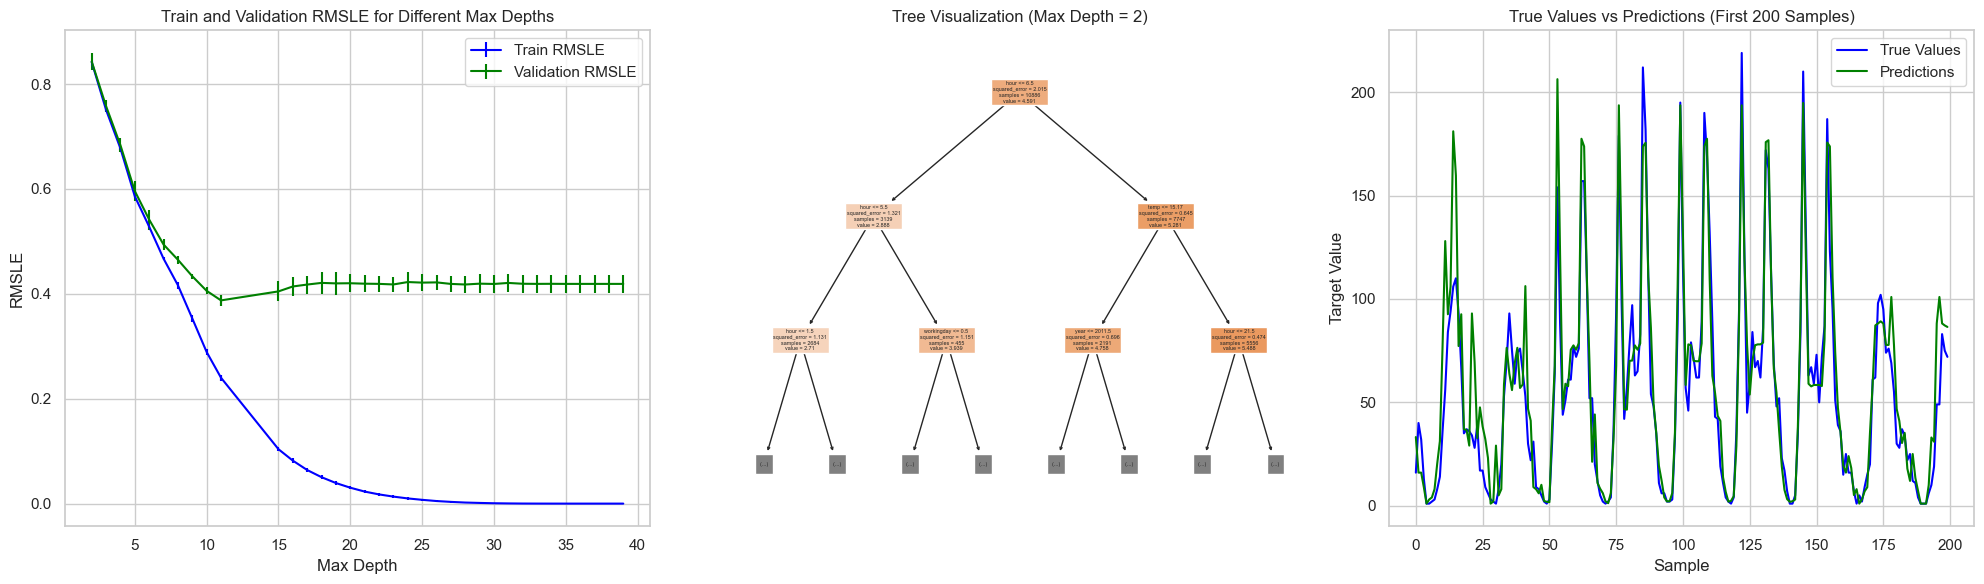

Best RMSLE: 0.3874924004063852
Best Max Depth: 11


In [37]:
# Definir los hiperparámetros a ajustar
param_grid = {
    'transformed_target_regressor__regressor__max_depth': list(range(2, 12, 1)) + [11] + list(range(15, 40, 1))
}

# Inicializar la búsqueda de hiperparámetros
grid_search = GridSearchCV(estimator=regression_pipeline, param_grid=param_grid, 
                           scoring=rmsle_scorer, cv = KFold(n_splits=10, shuffle=True, random_state=2), return_train_score=True)

# Ejecutar la búsqueda de hiperparámetros
grid_search.fit(df_train, y_train)

# Obtener los resultados de la búsqueda
best_estimator = grid_search.best_estimator_
best_params = grid_search.best_params_
best_rmsle = -grid_search.best_score_

# Graficar los valores de RMSLE de entrenamiento y validación
train_scores = -grid_search.cv_results_['mean_train_score']
test_scores = -grid_search.cv_results_['mean_test_score']
train_std = grid_search.cv_results_['std_train_score']
test_std = grid_search.cv_results_['std_test_score']
depth_values = param_grid['transformed_target_regressor__regressor__max_depth']


fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1 - Train and Validation RMSLE for Different Max Depths
axs[0].errorbar(depth_values, train_scores, yerr=train_std, label='Train RMSLE', color='blue')
axs[0].errorbar(depth_values, test_scores, yerr=test_std, label='Validation RMSLE', color='green')
axs[0].set_title('Train and Validation RMSLE for Different Max Depths')
axs[0].set_xlabel('Max Depth')
axs[0].set_ylabel('RMSLE')
axs[0].legend()

# Plot 2 - Visualizar el árbol hasta los nodos de profundidad 2
plot_tree(best_estimator.named_steps['transformed_target_regressor'].regressor_,
          max_depth=2, feature_names=df_train.columns, filled=True, ax=axs[1])
axs[1].set_title('Tree Visualization (Max Depth = 2)')

# Plot 3 - Graficar los primeros 200 valores objetivo junto con sus predicciones
predictions = cross_val_predict(best_estimator, df_train, y_train, cv=kf)
axs[2].plot(y_train[:200], label='True Values', color='blue')
axs[2].plot(predictions[:200], label='Predictions', color='green')
axs[2].set_title('True Values vs Predictions (First 200 Samples)')
axs[2].set_xlabel('Sample')
axs[2].set_ylabel('Target Value')
axs[2].legend()

plt.tight_layout()
plt.show()

# Mostrar el mejor valor RMSLE y el valor del hiperparámetro
print("Best RMSLE:", best_rmsle)
print("Best Max Depth:", best_params['transformed_target_regressor__regressor__max_depth'])


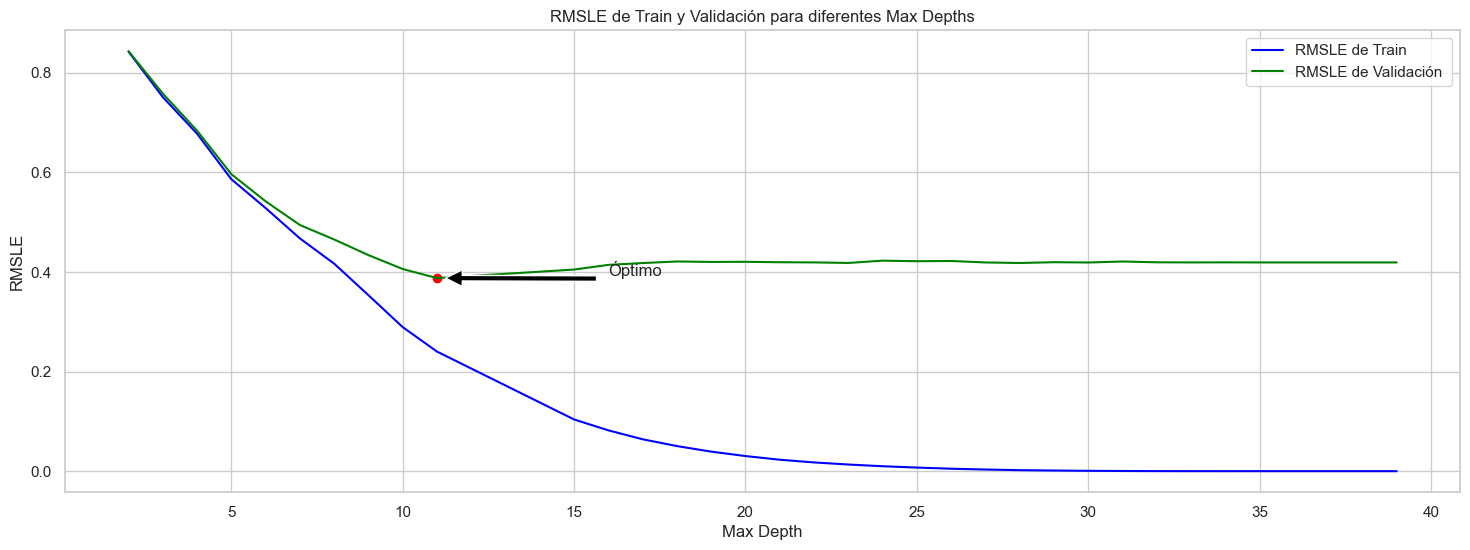

In [68]:
# Encontrar el índice del valor mínimo en test_scores
min_index = np.argmin(test_scores)

# Graficar los valores de RMSLE de entrenamiento y validación
plt.figure(figsize=(18, 6))  # Ajustar tamaño de la figura (ancho, alto)
plt.errorbar(depth_values, train_scores,  label='RMSLE de Train ', color='blue')
plt.errorbar(depth_values, test_scores,  label='RMSLE de Validación ', color='green')
plt.scatter(depth_values[min_index], test_scores[min_index], color='red')  # Marcar el mínimo en la gráfica
plt.annotate('Óptimo', xy=(depth_values[min_index], test_scores[min_index]), xytext=(depth_values[min_index] + 5, test_scores[min_index] + 0.005),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)  # Añadir la etiqueta "óptimo" con una flecha
plt.title('RMSLE de Train y Validación para diferentes Max Depths')
plt.xlabel('Max Depth')
plt.ylabel('RMSLE')
plt.legend()
plt.grid(True) # Agregar cuadrícula
plt.show()


Mean Train RMSLE for Random Forest: 0.24000572270366655
Mean Val RMSLE for Random Forest: 0.3874924004063852
Best Max Depth for Random Forest: 11


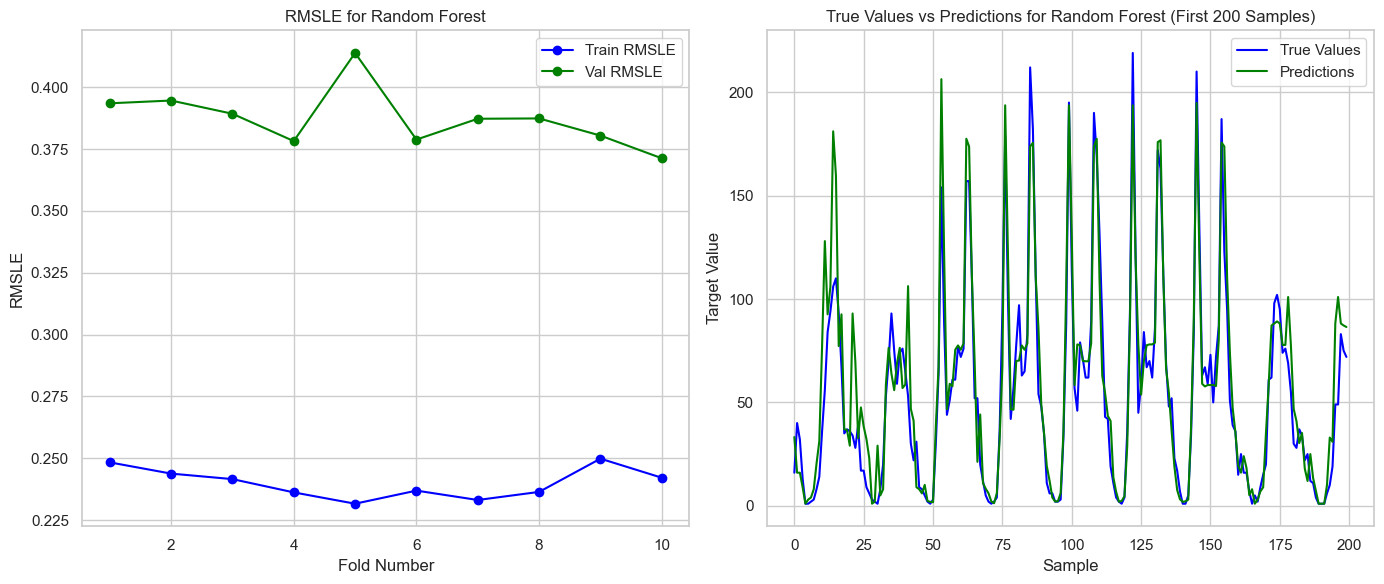

In [89]:
# Decision Tree con el mejor
best_estimator_dt = grid_search.best_estimator_

dt_regressor = DecisionTreeRegressor(random_state=2, 
                                         max_depth=best_params['transformed_target_regressor__regressor__max_depth'])

regressor = TransformedTargetRegressor(regressor=dt_regressor,
                                          func=np.log1p, 
                                          inverse_func=np.expm1)

decision_tree_pipeline = Pipeline([
    ('regressor', regressor)
])


# Definir KFold para uso repetido
kf = KFold(n_splits=10, shuffle=True, random_state=2)

# Entrenar el modelo Random Forest y obtener RMSLE con validación cruzada
train_scores_rf = []
val_scores_rf = []

for train_index, val_index in kf.split(df_train):
    X_train_fold, X_val_fold = df_train.iloc[train_index], df_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    decision_tree_pipeline.fit(X_train_fold, y_train_fold)
    
    train_predictions = decision_tree_pipeline.predict(X_train_fold)
    val_predictions = decision_tree_pipeline.predict(X_val_fold)
    
    train_rmsle = rmsle(y_train_fold, train_predictions)
    val_rmsle = rmsle(y_val_fold, val_predictions)
    
    train_scores_rf.append(train_rmsle)
    val_scores_rf.append(val_rmsle)
# Calcular el promedio de RMSLE para Random Forest
mean_train_rmsle_rf = np.mean(train_scores_rf)
mean_val_rmsle_rf = np.mean(val_scores_rf)

print("Mean Train RMSLE for Random Forest:", mean_train_rmsle_rf)
print("Mean Val RMSLE for Random Forest:", mean_val_rmsle_rf)
print("Best Max Depth for Random Forest:", best_params['transformed_target_regressor__regressor__max_depth'])

# Graficar RMSLE para Random Forest
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - RMSLE for Random Forest
axs[0].plot(range(1, 11), train_scores_rf, marker='o', label='Train RMSLE', color='blue')
axs[0].plot(range(1, 11), val_scores_rf, marker='o', label='Val RMSLE', color='green')
axs[0].set_title('RMSLE for Random Forest')
axs[0].set_xlabel('Fold Number')
axs[0].set_ylabel('RMSLE')
axs[0].legend()

# Plot 2 - True Values vs Predictions for Random Forest (First 200 Samples)
predictions_rf = cross_val_predict(decision_tree_pipeline, df_train, y_train, cv=kf)
axs[1].plot(y_train[:200], label='True Values', color='blue')
axs[1].plot(predictions_rf[:200], label='Predictions', color='green')
axs[1].set_title('True Values vs Predictions for Random Forest (First 200 Samples)')
axs[1].set_xlabel('Sample')
axs[1].set_ylabel('Target Value')
axs[1].legend()

plt.tight_layout()
plt.show()


In [40]:
exp = Experiment(api_key=API_KEY,  
                 project_name='Problema de las bicis', # Nombre del proyecto donde se registran los experimentos
                 auto_param_logging=False) 
exp.set_name('Validación cruzada Decision Tree') # Nombre de este experimento
exp.add_tags(['Básico']) # Tags

save_experiment_results(exp, train_scores_rf, val_scores_rf, kf)
exp.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/nahu-pi-eyro/problema-de-las-bicis/01ffd229e49d47418ef10da62f8f543f

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/nahu-pi-eyro/problema-de-las-bicis/01ffd229e49d47418ef10da62f8f543f
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Train RMSLE [10] : (0.2319182381197418, 0.25288339070225957)
COMET INFO:     Val RMSLE [10]   : (0.3785478215485314, 0.42010726368161677)
COMET INFO:   Others:
COMET INFO:     Name : Validación cruzada 

## Parte 5 - Random Forest

#### Preguntas sobre métodos de Ensamble:

*   ¿Cuáles son las ventajes de los métodos de Ensamble?
*   ¿A qué métodos de ensamble está asociado *Random Forest*?.
*   Importar la función *RandomForestRegressor()* de *Scikit-Learn*.
*   Indicar y describir los principales hiper-parámetros correspondientes a los métodos de ensamble que ofrece la función.




### Respuesta: Ventajas de los métodos de Ensamble:

1) Mejora del rendimiento predictivo: Los métodos de ensamble combinan múltiples modelos base para mejorar la precisión y generalización del modelo.
2) Reducción del sobreajuste: Al combinar múltiples modelos, los métodos de ensamble pueden reducir el riesgo de sobreajuste y mejorar la capacidad del modelo para generalizar a datos no vistos.
3) Robustez: Los métodos de ensamble suelen ser más robustos que los modelos individuales, ya que tienen en cuenta múltiples perspectivas y enfoques.
4) Versatilidad: Los métodos de ensamble pueden aplicarse a una variedad de problemas de aprendizaje supervisado y pueden ser adaptados para diferentes tipos de datos y modelos base.

#### Métodos de ensamble asociados a Random Forest:

1) Random Forest es un método de ensamble basado en árboles de decisión.
2) También está relacionado con métodos como Bagging y Boosting, aunque Random Forest utiliza una técnica específica de subconjuntos aleatorios para construir múltiples árboles.
3) Importar la función RandomForestRegressor() de Scikit-Learn:

In [41]:
from sklearn.ensemble import RandomForestRegressor

**Principales hiperparámetros correspondientes a los métodos de ensamble ofrecidos por RandomForestRegressor:**
   - `n_estimators`: El número de árboles en el bosque.
   - `criterion`: La función para medir la calidad de una división. Puede ser "mse" para el error cuadrático medio o "mae" para el error absoluto medio.
   - `max_depth`: La profundidad máxima de cada árbol en el bosque.
   - `min_samples_split`: El número mínimo de muestras necesarias para dividir un nodo interno.
   - `min_samples_leaf`: El número mínimo de muestras necesarias en un nodo hoja.
   - `max_features`: El número de características a considerar al buscar la mejor división.
   - `bootstrap`: Si se deben realizar muestras bootstrap al construir árboles.  (Muestro aleatorio con remplazo)
   - `random_state`: Semilla para controlar la aleatoriedad del proceso de ajuste.
   - Otros hiperparámetros están disponibles para ajustar la velocidad de entrenamiento, la precisión y el control de la complejidad del modelo.

#### Ajuste fino



*   Encontrar el mejor estimador para *Random Forest* usando como estimador base el encontrado en la parte 4.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Comparar con los resultados correspondientes de la parte 4.
*   Mostrar el mejor valor de RMSLE (promedio de todos los folds) y compararlo con el de la parte 4. Mostrar los valores seleccionados de los hiper-parámetros.
*   ¿Qué ventaja se pierde con repecto a usar un sólo árbol?
*   Graficar los primeros 200 valores objetivo junto con sus predicciones. Comparar con el gráfico correspondiente de la parte 4.
*   Mostrar la importancia de cada característica utilizando la variable *feature_importances_*.



Mean Train RMSLE for Random Forest: 0.20860653973706386
Mean Val RMSLE for Random Forest: 0.313154336562125
Best Max Depth for Random Forest: 11


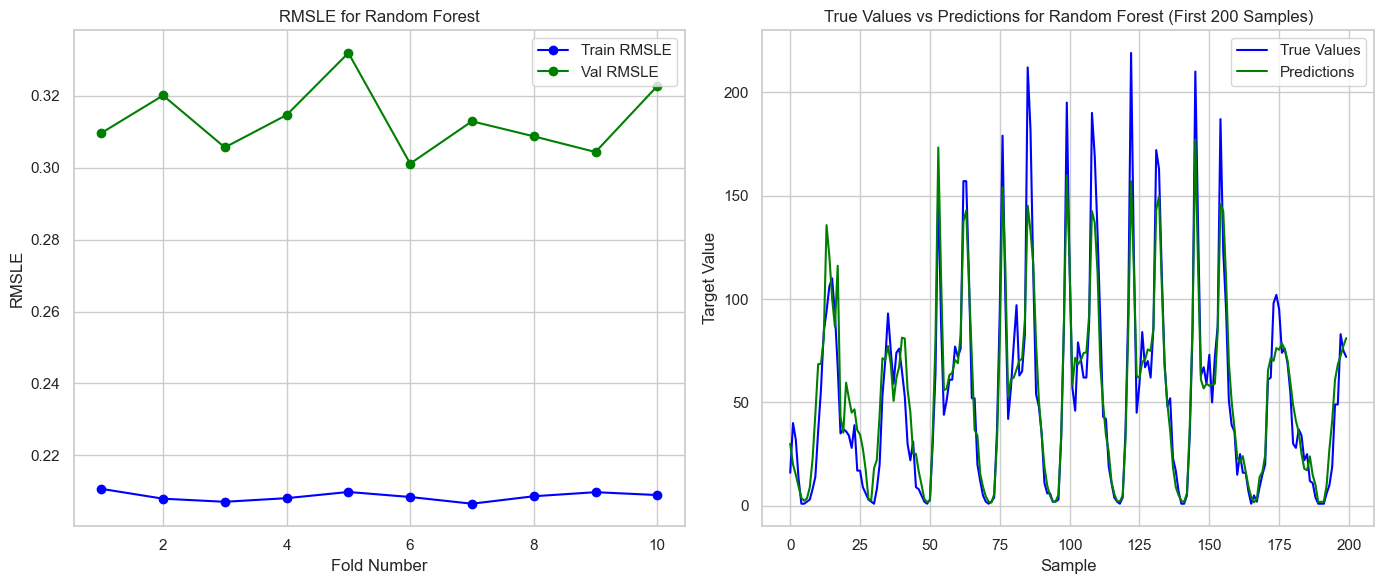

In [91]:
# Random Forest con el mejor
best_estimator_dt = grid_search.best_estimator_


dt_regressor =  RandomForestRegressor(random_state=2, 
                                         n_estimators=100,  
                                         max_depth=best_params['transformed_target_regressor__regressor__max_depth'])

regressor = TransformedTargetRegressor(regressor=dt_regressor,
                                          func=np.log1p, 
                                          inverse_func=np.expm1)

random_forest_pipeline = Pipeline([
    ('regressor', regressor)
])

# Definir KFold para uso repetido
kf = KFold(n_splits=10, shuffle=True, random_state=2)

# Entrenar el modelo Random Forest y obtener RMSLE con validación cruzada
train_scores_rf = []
val_scores_rf = []

for train_index, val_index in kf.split(df_train):
    X_train_fold, X_val_fold = df_train.iloc[train_index], df_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    random_forest_pipeline.fit(X_train_fold, y_train_fold)
    
    train_predictions = random_forest_pipeline.predict(X_train_fold)
    val_predictions = random_forest_pipeline.predict(X_val_fold)
    
    train_rmsle = rmsle(y_train_fold, train_predictions)
    val_rmsle = rmsle(y_val_fold, val_predictions)
    
    train_scores_rf.append(train_rmsle)
    val_scores_rf.append(val_rmsle)
# Calcular el promedio de RMSLE para Random Forest
mean_train_rmsle_rf = np.mean(train_scores_rf)
mean_val_rmsle_rf = np.mean(val_scores_rf)

print("Mean Train RMSLE for Random Forest:", mean_train_rmsle_rf)
print("Mean Val RMSLE for Random Forest:", mean_val_rmsle_rf)
print("Best Max Depth for Random Forest:", best_params['transformed_target_regressor__regressor__max_depth'])

# Graficar RMSLE para Random Forest
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - RMSLE for Random Forest
axs[0].plot(range(1, 11), train_scores_rf, marker='o', label='Train RMSLE', color='blue')
axs[0].plot(range(1, 11), val_scores_rf, marker='o', label='Val RMSLE', color='green')
axs[0].set_title('RMSLE for Random Forest')
axs[0].set_xlabel('Fold Number')
axs[0].set_ylabel('RMSLE')
axs[0].legend()

# Plot 2 - True Values vs Predictions for Random Forest (First 200 Samples)
predictions_rf = cross_val_predict(random_forest_pipeline, df_train, y_train, cv=kf)
axs[1].plot(y_train[:200], label='True Values', color='blue')
axs[1].plot(predictions_rf[:200], label='Predictions', color='green')
axs[1].set_title('True Values vs Predictions for Random Forest (First 200 Samples)')
axs[1].set_xlabel('Sample')
axs[1].set_ylabel('Target Value')
axs[1].legend()

plt.tight_layout()
plt.show()


In [92]:
exp = Experiment(api_key=API_KEY,  
                 project_name='Problema de las bicis', # Nombre del proyecto donde se registran los experimentos
                 auto_param_logging=False) 
exp.set_name('Validación cruzada Random Forest') # Nombre de este experimento
exp.add_tags(['Básico']) # Tags

save_experiment_results(exp, train_scores_rf, val_scores_rf, kf)
exp.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/nahu-pi-eyro/problema-de-las-bicis/587eb8dab6dc43c8b5760205b491e852

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/nahu-pi-eyro/problema-de-las-bicis/587eb8dab6dc43c8b5760205b491e852
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Train RMSLE [10] : (0.20656431475687573, 0.2107023102245423)
COMET INFO:     Val RMSLE [10]   : (0.301115683101253, 0.3318840392083527)
COMET INFO:   Others:
COMET INFO:     Name : Validación cruzada Ra

## Parte 6 - Gradient Boosting


#### XGBoost

*   Indicar cuál es la principal diferencia entre *Bagging* y *Boosting*.
*   Importar la función *XGBRegressor()* de la librería [*xgboost*](https://github.com/dmlc/xgboost).
*   Este estimador a diferencia de los anteriores puede devolver predicciones negativas para estos datos. Indicar en que caso se pueda dar esto y por qué esto no sucedía con los estimadores anteriores.
*   Las predicciones negativas no pueden ser evaluadas por RMSLE. Por lo tanto, crear una nueva función de evaluación que fuerce a cero todos los valores negativos de las predicciones y luego calcule el valor de RMSLE. Para esto se debe utilizar la función *make_score* de *Sickit-Learn*, para que la nueva función pueda ser utilizada en las funciones de selección de modelos.


**Nota:** *Scikit-Learn* ofrece una implementación de *Gradient Boosting*, pero *XGBRegressor()* es la implementación de [*eXtreme Gradient Boosting*](https://arxiv.org/pdf/1603.02754.pdf?__hstc=133736337.1bb630f9cde2cb5f07430159d50a3c91.1513641600097.1513641600098.1513641600099.1&__hssc=133736337.1.1513641600100&__hsfp=528229161) un variante del algoritmo tradicional que dentro de algunas ventajas requiere menos tiempo de entrenamiento. La implementación de las funciones de la librería son muy similares a las de *Scikit-Learn*, de igual forma aquí le dejamos un [ejemplo](https://www.kaggle.com/alexisbcook/xgboost) de cómo usarla. 







**Nota:** A partir de la versión **0.21** *Scikit-Learn* también ofrece una implementación de *Gradient Boosting* optimizada para data-sets grandes: [Histogram-based Gradient Boosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html). Su funcionamiento se basa en agrupar en *bins* a los features de entrada, remplazandolos por integers. El número de *bins* es controlado por el hiperparámetro *max_bins*, el cual por defecto toma el valor 255 y no puede ser seteado a un valor mayor que este. En el Capítulo 7 del libro se encuentra más información acerca de este algoritmo. 

#### Respuesta:

* La principal diferencia entre *Bagging* y *Boosting* radica en cómo se construyen los modelos. En *Bagging*, se construyen múltiples modelos de manera independiente y luego se combinan sus predicciones, mientras que en *Boosting*, los modelos se construyen secuencialmente, y cada modelo intenta corregir los errores del modelo anterior.

* Para importar la función *XGBRegressor()* de la librería *xgboost*, puedes hacerlo de la siguiente manera en Python:

In [93]:
from xgboost import XGBRegressor

* En el caso de *XGBRegressor()*, las predicciones negativas pueden ocurrir cuando el modelo predice valores por debajo de cero. Esto puede suceder si el modelo aprende una tendencia negativa en los datos o si hay características no representadas adecuadamente en el conjunto de entrenamiento que llevan a tales predicciones. Esto puede no haber sucedido con estimadores anteriores debido a diferencias en la forma en que se construyen los modelos o cómo se manejan los datos.

* Para crear una nueva función de evaluación que fuerce a cero todos los valores negativos de las predicciones y luego calcule el valor de RMSLE, puedes usar la función `make_scorer` de Scikit-Learn. Aquí hay un ejemplo de cómo hacerlo:

In [94]:
def custom_rmsle(y_true, y_pred):
    y_pred_non_negative = np.maximum(y_pred, 0)  # Forzar valores negativos a cero
    return np.sqrt(mean_squared_log_error(y_true, y_pred_non_negative))

# Crear un scorer personalizado
rmsle_scorer = make_scorer(custom_rmsle, greater_is_better=False)

Esto te permite usar `custom_rmsle` como una métrica en las funciones de selección de modelos de Scikit-Learn.

#### Ajuste fino



*   Encontrar el mejor estimador para *Gradient Boosting* usando como estimador base el encontrado en la parte 4.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Comparar con los gráficos correspondientes.
*   Mostrar el mejor valor de RMSLE (promedio de todos los folds) y compararlo con los anteriores. Mostrar los valores seleccionados de los hiper-parámetros.
*   Graficar los primeros 200 valores objetivo junto con sus predicciones. Comparar con los gráficos corespondientes.
*   ¿Qué compromiso hay entre los hiper-parámetros *n_estimators* y *learning_rate*?



COMET WARNING: You must install graphviz to plot tree


Mean Train RMSLE for Random Forest: 0.0080593914729645
Mean Val RMSLE for Random Forest: 0.30271662420994067


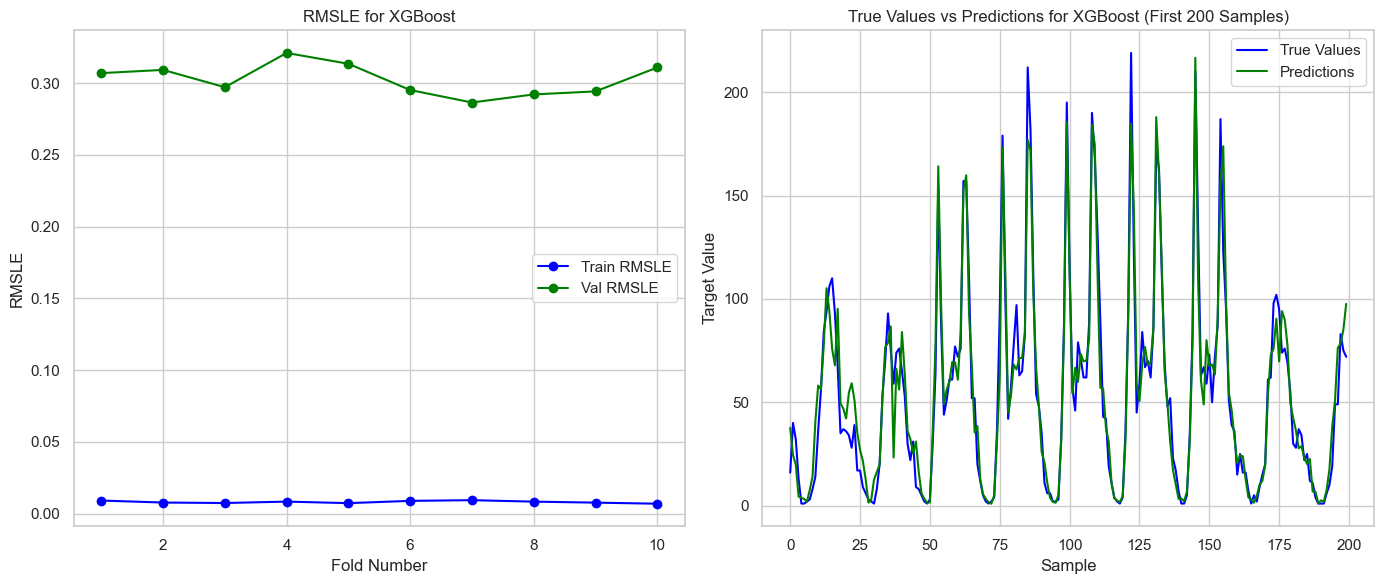

In [95]:
# XGBoost con el mejor

best_estimator_dt = grid_search.best_estimator_


dt_regressor =  XGBRegressor(
        random_state=42,
        n_estimators=100,  # Puedes ajustar este valor si lo deseas
        max_depth=best_params['transformed_target_regressor__regressor__max_depth']
    )

regressor = TransformedTargetRegressor(regressor=dt_regressor,
                                          func=np.log1p, 
                                          inverse_func=np.expm1)

xgb_pipeline = Pipeline([
    ('regressor', regressor)
])


# Definir KFold para uso repetido
kf = KFold(n_splits=10, shuffle=True, random_state=2)

# Entrenar el modelo XGBoost y obtener RMSLE con validación cruzada
train_scores_xgb = []
val_scores_xgb = []

for train_index, val_index in kf.split(df_train):
    X_train_fold, X_val_fold = df_train.iloc[train_index], df_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    xgb_pipeline.fit(X_train_fold, y_train_fold)
    
    train_predictions = xgb_pipeline.predict(X_train_fold)
    val_predictions = xgb_pipeline.predict(X_val_fold)
    
    train_rmsle = custom_rmsle(y_train_fold, train_predictions)
    val_rmsle = custom_rmsle(y_val_fold, val_predictions)
    
    train_scores_xgb.append(train_rmsle)
    val_scores_xgb.append(val_rmsle)

# Calcular el promedio de RMSLE para XGBoost
mean_train_rmsle_xgb = np.mean(train_scores_xgb)
mean_val_rmsle_xgb = np.mean(val_scores_xgb)

# Graficar RMSLE para XGBoost
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

print("Mean Train RMSLE for Random Forest:", mean_train_rmsle_xgb)
print("Mean Val RMSLE for Random Forest:", mean_val_rmsle_xgb)

# Plot 1 - RMSLE for XGBoost
axs[0].plot(range(1, 11), train_scores_xgb, marker='o', label='Train RMSLE', color='blue')
axs[0].plot(range(1, 11), val_scores_xgb, marker='o', label='Val RMSLE', color='green')
axs[0].set_title('RMSLE for XGBoost')
axs[0].set_xlabel('Fold Number')
axs[0].set_ylabel('RMSLE')
axs[0].legend()

# Plot 2 - True Values vs Predictions for XGBoost (First 200 Samples)
predictions_xgb = cross_val_predict(xgb_pipeline, df_train, y_train, cv=kf)
axs[1].plot(y_train[:200], label='True Values', color='blue')
axs[1].plot(predictions_xgb[:200], label='Predictions', color='green')
axs[1].set_title('True Values vs Predictions for XGBoost (First 200 Samples)')
axs[1].set_xlabel('Sample')
axs[1].set_ylabel('Target Value')
axs[1].legend()

plt.tight_layout()
plt.show()

In [96]:
exp = Experiment(api_key=API_KEY,  
                 project_name='Problema de las bicis', # Nombre del proyecto donde se registran los experimentos
                 auto_param_logging=False) 
exp.set_name('Validación cruzada XGBoost') # Nombre de este experimento
exp.add_tags(['Básico']) # Tags

save_experiment_results(exp, train_scores_xgb, val_scores_xgb, kf)
exp.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/nahu-pi-eyro/problema-de-las-bicis/bca4b32cdc19467f91b50619de9b099f

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/nahu-pi-eyro/problema-de-las-bicis/bca4b32cdc19467f91b50619de9b099f
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Train RMSLE [10] : (0.006857048087095775, 0.009323201133878271)
COMET INFO:     Val RMSLE [10]   : (0.2865293594333387, 0.3210718690167952)
COMET INFO:   Others:
COMET INFO:     Name : Validación cruzad

## Parte 7 - Custom Transformers 

- Construir un *Custom Transformer* que extraiga las caracterísicas temporales, siguiendo el ejemplo del capítulo 2 del libro.

In [97]:
from sklearn.base import BaseEstimator, TransformerMixin

class DateTimeFeaturesAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        # Asegurarse de que la columna 'datetime' sea de tipo datetime
        if 'datetime' in X.columns:
            X['datetime'] = pd.to_datetime(X['datetime'])
        
        # Añadir columnas 'day', 'month', 'year', 'hour' y 'weekday' según el datetime
        X['day'] = X['datetime'].dt.day
        X['month'] = X['datetime'].dt.month
        X['year'] = X['datetime'].dt.year
        X['hour'] = X['datetime'].dt.hour
        X['weekday'] = X['datetime'].dt.weekday
        
        return X

## Parte 8 - Generar un modelo

#### Objetivos:

 - Generar el mejor modelo posible. Se podrá explorar posibles mejoras en cualquiera de las siguientes etapas:

    - Parámetros óptimos del regresor.
    - Predicción de alquileres registered y casual por separado.
    - Separación de conjunto de Entrenamiento y Validación tomando en cuenta la generación del conjunto de Test del desafío.
    - Cambios en las características utilizadas. (Agregando o quitando alguna de ellas)

In [98]:
# Entrenamiento del mejor modelo sin GridSearchCV
xgb_pipeline.fit(df_train, y_train)

exp.set_name("Mejor Modelo")
exp.add_tags(["Avanzado", "Sin_GridSearchCV"])

# Guardar el mejor modelo en el sistema de archivos
model_filename = "Modelo Random Forest"
joblib.dump(xgb_pipeline, model_filename)

# Subir el modelo como un artefacto de Comet.ml
exp.log_model("Mejor Modelo sin GridSearchCV", model_filename)

# No olvides cerrar el experimento
exp.end()


## Parte 9 - Submit
Construir un *pipeline* para el estimador que consideren que tuvo mejor desempeño. El pre-procesamiento debe incluir la extracción de las nuevas características.

Subir los resultados del *pipeline* para los datos de *test*,  a la [página](https://www.kaggle.com/c/bike-sharing-demand/submissions) de la competencia.

In [101]:
df_test = pd.read_csv('test.csv')
df_test_original = pd.read_csv('test.csv')
df_submission = pd.read_csv('sampleSubmission.csv')

In [102]:
# Asegurarse de que df_test es procesado de la misma forma que df_train
df_test['datetime'] = pd.to_datetime(df_test['datetime'])
df_test['day'] = df_test['datetime'].dt.day
df_test['month'] = df_test['datetime'].dt.month
df_test['year'] = df_test['datetime'].dt.year
df_test['hour'] = df_test['datetime'].dt.hour
df_test['weekday'] = df_test['datetime'].dt.weekday

# Ahora elimina la columna 'datetime' de df_test, ya que no se usa en el entrenamiento
df_test = df_test.drop(['datetime'], axis=1)

# Verificación para asegurarse de que df_test y df_train tengan las mismas columnas
print(df_train.columns)
print(df_test.columns)

# Si los conjuntos de datos están alineados correctamente, procede con el entrenamiento y la predicción
xgb_pipeline.fit(df_train, y_train)
xgb_pipeline_predictions = xgb_pipeline.predict(df_test)


Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'day', 'month', 'year', 'hour', 'weekday'],
      dtype='object')
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'day', 'month', 'year', 'hour', 'weekday'],
      dtype='object')




*   ¿Cuánto fue el valor de RMSLE para el conjunto de test?


In [103]:
# Suponemos que tienes acceso al DataFrame original de test con la columna 'datetime'
# Si lo has eliminado, asegúrate de tener alguna forma de reconstruirlo o mantenerlo para el submission
df_submission = pd.DataFrame({
    'datetime': df_test_original['datetime'],  # Asegúrate de utilizar el df original antes de eliminar 'datetime'
    'count': xgb_pipeline_predictions  # Usamos las predicciones directamente
})

# Asegurarte de que las predicciones no tengan valores negativos
df_submission['count'] = df_submission['count'].clip(lower=0)

# Guardar el DataFrame a un archivo CSV
df_submission.to_csv('submission.csv', index=False)

# Muestra las primeras filas para verificar
print(df_submission.head())


              datetime     count
0  2011-01-20 00:00:00  9.755058
1  2011-01-20 01:00:00  6.387986
2  2011-01-20 02:00:00  6.283468
3  2011-01-20 03:00:00  2.157218
4  2011-01-20 04:00:00  2.091577
